### Vergleich der Datensätze

In [3]:
# quick_distribution_compare.py
import re
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
from scipy.stats import shapiro

# ======= NUR HIER ANPASSEN =======
PATH_MIXED  = r"K:\Team\Böhmer_Michael\PAPER\Finale_Versionen_ML_Vergleich\Basistabelle_ML_reduziert.xlsx"
PATH_MALE   = r"K:\Team\Böhmer_Michael\PAPER\Finale_Versionen_ML_Vergleich\Basistabelle_ML_reduziert_male.xlsx"
PATH_EXTERN = r"K:\Team\Böhmer_Michael\PAPER\Finale_Versionen_ML_Vergleich\Basistabelle_Maestroni_ML.xlsx"

# Spalten, die ignoriert werden sollen (z. B. Ziel/IDs); case/whitespace-robust
IGNORE_COLS = ["Verletzungsstatus", "Geschlecht_weiblich"]
# =================================

def norm_header(s: str) -> str:
    if s is None:
        return ""
    s = str(s)
    s = s.replace("\u00A0", " ").replace("\u2009", " ").replace("\u202F", " ").replace("\u2007", " ")
    s = re.sub(r"[_\-\–\—/\\\|\;]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"\.\s*$", "", s)
    return s.lower()

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    cols = [norm_header(c) for c in df.columns]
    seen = {}
    final = []
    for c in cols:
        if c not in seen:
            seen[c] = 1
            final.append(c)
        else:
            seen[c] += 1
            final.append(f"{c}_dup{seen[c]}")
    out = df.copy()
    out.columns = final
    return out

def load_table(path) -> pd.DataFrame:
    # immer erstes Blatt laden
    df = pd.read_excel(path, sheet_name=0)
    return normalize_columns(df)

def is_numeric_series(s: pd.Series) -> bool:
    sn = pd.to_numeric(s, errors="coerce")
    return sn.notna().any()

def cohen_d(a: np.ndarray, b: np.ndarray) -> float:
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return np.nan
    va, vb = np.var(a, ddof=1), np.var(b, ddof=1)
    sp2 = ((na - 1)*va + (nb - 1)*vb) / (na + nb - 2)
    if sp2 <= 0:
        return np.nan
    return (np.mean(a) - np.mean(b)) / np.sqrt(sp2)

def summary(s: pd.Series):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if s.empty:
        return dict(n=0, mean=np.nan, sd=np.nan, median=np.nan, 
                    min=np.nan, max=np.nan, shapiro_p=np.nan)
    # Shapiro-Wilk-Test (nur wenn n >= 3 und n <= 5000 empfohlen)
    if 3 <= len(s) <= 5000:
        shapiro_p = shapiro(s).pvalue
    else:
        shapiro_p = np.nan
    return dict(
        n=int(s.size),
        mean=float(s.mean()),
        sd=float(s.std(ddof=1)) if s.size > 1 else 0.0,
        median=float(s.median()),
        min=float(s.min()),
        max=float(s.max()),
        shapiro_p=float(shapiro_p)
    )

def print_feature_block(name: str, mix: pd.Series, male: pd.Series, ext: pd.Series):
    sm = summary(mix)
    sa = summary(male)
    se = summary(ext)

    print(f"\nFeature: {name}")
    print("-"*96)
    print(f"{'Group':<10} {'n':>6} {'Mean':>10} {'SD':>10} {'Median':>10} "
          f"{'Min':>8} {'Max':>8} {'Shap-p':>10}")
    print(f"{'Mixed':<10} {sm['n']:>6} {sm['mean']:>10.3f} {sm['sd']:>10.3f} {sm['median']:>10.3f} "
          f"{sm['min']:>8.3f} {sm['max']:>8.3f} {sm['shapiro_p']:>10.3f}")
    print(f"{'Male':<10}  {sa['n']:>6} {sa['mean']:>10.3f} {sa['sd']:>10.3f} {sa['median']:>10.3f} "
          f"{sa['min']:>8.3f} {sa['max']:>8.3f} {sa['shapiro_p']:>10.3f}")
    print(f"{'External':<10}{se['n']:>6} {se['mean']:>10.3f} {se['sd']:>10.3f} {se['median']:>10.3f} "
          f"{se['min']:>8.3f} {se['max']:>8.3f} {se['shapiro_p']:>10.3f}")

    comps = [
        ("Mixed vs Male", mix, male),
        ("Mixed vs External", mix, ext),
        ("Male vs External", male, ext),
    ]

    print("\nComparisons   ΔMean      d        KS-p")
    for label, s1, s2 in comps:
        x = pd.to_numeric(s1, errors="coerce").dropna().values
        y = pd.to_numeric(s2, errors="coerce").dropna().values
        if x.size >= 2 and y.size >= 2:
            delta = float(np.nanmean(x) - np.nanmean(y))
            d = cohen_d(x, y)
            ks_p = float(ks_2samp(x, y, alternative="two-sided", mode="auto").pvalue)
            print(f"{label:<16}{delta:>+7.3f}  {d:>7.3f}   {ks_p:>7.3g}")
        else:
            print(f"{label:<16}{'n/a':>7}   {'n/a':>7}   {'n/a':>7}")

def main():
    df_mix  = load_table(PATH_MIXED)
    df_male = load_table(PATH_MALE)
    df_ext  = load_table(PATH_EXTERN)

    ignore = {norm_header(c) for c in IGNORE_COLS}
    common = set(df_mix.columns) & set(df_male.columns) & set(df_ext.columns)
    common = [c for c in common if c not in ignore]

    numeric_common = []
    for c in sorted(common):
        if is_numeric_series(df_mix[c]) or is_numeric_series(df_male[c]) or is_numeric_series(df_ext[c]):
            numeric_common.append(c)

    print(f"\nGemeinsame numerische Features: {len(numeric_common)}")
    if not numeric_common:
        print("Nichts zu vergleichen."); return

    for feat in numeric_common:
        print_feature_block(
            name=feat,
            mix=df_mix[feat],
            male=df_male[feat],
            ext=df_ext[feat]
        )

if __name__ == "__main__":
    main()



Gemeinsame numerische Features: 18

Feature: cmj propulsive duration
------------------------------------------------------------------------------------------------
Group           n       Mean         SD     Median      Min      Max     Shap-p
Mixed         108      0.305      0.055      0.299    0.218    0.633      0.000
Male            68      0.300      0.042      0.299    0.218    0.394      0.609
External      67      0.275      0.034      0.273    0.179    0.369      0.953

Comparisons   ΔMean      d        KS-p
Mixed vs Male    +0.005    0.099         1
Mixed vs External +0.031    0.634   0.000531
Male vs External +0.026    0.669   0.00102

Feature: inv cmj uni av. propulsive force
------------------------------------------------------------------------------------------------
Group           n       Mean         SD     Median      Min      Max     Shap-p
Mixed         108      8.890      0.973      8.814    6.189   11.737      0.750
Male            68      9.136      0.988  

### Metrikvergleich 

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, BaggingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.width", 200)

def repeated_k_fold(model, X, y, n_splits=5, n_repeats=10):
    rkf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

    accuracy_train, accuracy_test = [], []
    f1, recall, roc_auc = [], [], []

    for train_index, test_index in rkf.split(X, y):
        # Aufteilen in Trainings- und Testdaten
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Skalierung: nur an den Trainingsdaten fitten
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model.fit(X_train_scaled, y_train)

        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)

        accuracy_train.append(accuracy_score(y_train, y_train_pred))
        accuracy_test.append(accuracy_score(y_test, y_test_pred))
        f1.append(f1_score(y_test, y_test_pred))
        recall.append(recall_score(y_test, y_test_pred))
        roc_auc.append(roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1]))

    return {
        "Train Accuracy": (np.mean(accuracy_train), np.std(accuracy_train)),
        "Test Accuracy": (np.mean(accuracy_test), np.std(accuracy_test)),
        "F1-Score_1": (np.mean(f1), np.std(f1)),
        "Recall_1": (np.mean(recall), np.std(recall)),
        "ROC-AUC_1": (np.mean(roc_auc), np.std(roc_auc)),
    }


# Pfad zur Datei
file_path = r"K:\Team\Böhmer_Michael\PAPER\Finale_Versionen_ML_Vergleich\Basistabelle_ML_reduziert.xlsx"

try: 
    df = pd.read_excel(file_path)
    
    # Zielvariable (y) und Features (X) extrahieren
    y = df['Verletzungsstatus']
    
    # Dummy-Variable "Geschlecht_weiblich" separieren, falls vorhanden
    if 'Geschlecht_weiblich' in df.columns:
        geschlecht_weiblich = df[['Geschlecht_weiblich']]
        X = df.drop(columns=['Verletzungsstatus', 'Geschlecht_weiblich'])
        # Die Dummy-Variable wieder anhängen
        X = np.hstack((X.values, geschlecht_weiblich.values))
    else:
        X = df.drop(columns=['Verletzungsstatus']).values
    
    # Modelle definieren
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
        "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
        "LightGBM": LGBMClassifier(verbose=-1, random_state=42),
        "SVC": SVC(probability=True, random_state=42),
        "k-Nearest Neighbors": KNeighborsClassifier(),
        "MLP Classifier": MLPClassifier(max_iter=1000, random_state=42),
        "Gaussian Naive Bayes": GaussianNB(),
        "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
        "Quadratic Discriminant Analysis": QuadraticDiscriminantAnalysis(),
        "Bagging Classifier": BaggingClassifier(random_state=42),
        "Extra Trees": ExtraTreesClassifier(random_state=42),
    }
    
    results = []
    for model_name, model in models.items():
        print(f"Modell wird validiert: {model_name}")
        metrics = repeated_k_fold(model, X, y)
        
        formatted_metrics = {
            "Model": model_name,
            "Train Accuracy": f"{metrics['Train Accuracy'][0]:.4f} ± {metrics['Train Accuracy'][1]:.4f}",
            "Test Accuracy": f"{metrics['Test Accuracy'][0]:.4f} ± {metrics['Test Accuracy'][1]:.4f}",
            "F1-Score_1": f"{metrics['F1-Score_1'][0]:.4f} ± {metrics['F1-Score_1'][1]:.4f}",
            "Recall_1": f"{metrics['Recall_1'][0]:.4f} ± {metrics['Recall_1'][1]:.4f}",
            "ROC-AUC_1": f"{metrics['ROC-AUC_1'][0]:.4f} ± {metrics['ROC-AUC_1'][1]:.4f}",
        }
        results.append(formatted_metrics)
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by="ROC-AUC_1", ascending=False)
    
    print("\nErgebnisse der Modelle:")
    print(results_df)


except FileNotFoundError:
    print("Die Datei wurde nicht gefunden. Bitte überprüfe den Pfad.")
except Exception as e:
    print(f"Ein Fehler ist aufgetreten: {e}")

Modell wird validiert: Logistic Regression
Modell wird validiert: Decision Tree
Modell wird validiert: Random Forest
Modell wird validiert: Gradient Boosting
Modell wird validiert: XGBoost
Modell wird validiert: LightGBM
Modell wird validiert: SVC
Modell wird validiert: k-Nearest Neighbors
Modell wird validiert: MLP Classifier
Modell wird validiert: Gaussian Naive Bayes
Modell wird validiert: Linear Discriminant Analysis
Modell wird validiert: Quadratic Discriminant Analysis
Modell wird validiert: Bagging Classifier
Modell wird validiert: Extra Trees

Ergebnisse der Modelle:
                              Model   Train Accuracy    Test Accuracy       F1-Score_1         Recall_1        ROC-AUC_1
0               Logistic Regression  0.9495 ± 0.0122  0.8760 ± 0.0564  0.8744 ± 0.0583  0.8439 ± 0.0877  0.9548 ± 0.0344
8                    MLP Classifier  1.0000 ± 0.0000  0.8833 ± 0.0556  0.8845 ± 0.0546  0.8655 ± 0.0810  0.9494 ± 0.0407
6                               SVC  0.9512 ± 0.0131  0

### Überarbeitung Validierung

### Alter Validierung

In [ ]:
import numpy as np
import pandas as pd
import time
import os
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
from joblib import Parallel, delayed
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

# =============================================================================
# Kalibration und DCA
# =============================================================================

# --- Einzel-Fold: Calibration (mit Brier) ---
def compute_calibration(y_true, y_prob, n_bins=10):
    """
    Gibt Brier Score + (mean_pred, frac_pos) der Reliability-Kurve zurück.
    strategy='quantile' stabilisiert bei unbalancierten Klassen.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    bs = brier_score_loss(y_true, y_prob)
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy="quantile")
    return {"brier": bs, "mean_pred": mean_pred, "frac_pos": frac_pos}

# --- Einzel-Fold: DCA ---
def decision_curve(y_true, y_prob, thresholds=None):
    """
    Net Benefit nach Vickers & Elkin (2006).
    NB_model = (TP/N) - (FP/N) * (pt/(1-pt))
    NB_treat_all = prevalence - (1-prevalence)*(pt/(1-pt))
    NB_treat_none = 0
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    N = len(y_true)
    prevalence = y_true.mean()

    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)

    nb_model = []
    nb_all = []
    nb_none = np.zeros_like(thresholds)

    for pt in thresholds:
        pred = (y_prob >= pt).astype(int)
        TP = np.sum((pred == 1) & (y_true == 1))
        FP = np.sum((pred == 1) & (y_true == 0))
        weight = pt / (1 - pt)
        nb = (TP / N) - (FP / N) * weight
        nb_model.append(nb)

        nb_all_pt = prevalence - (1 - prevalence) * weight
        nb_all.append(nb_all_pt)

    return {
        "thresholds": np.array(thresholds),
        "nb_model": np.array(nb_model),
        "nb_all": np.array(nb_all),
        "nb_none": nb_none,
        "prevalence": prevalence
    }

# --- Aggregation über Folds: Calibration ---
def aggregate_calibration(cal_list, grid=None):
    """
    Interpoliert jede Fold-Kurve auf ein gemeinsames Gitter der vorhergesagten p.
    Liefert mean±sd der beobachteten Positivrate auf diesem Gitter + gemittelten Brier.
    """
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)  # 19 Punkte von 5% bis 95%

    # Interpolation: frac_pos als Funktion von mean_pred
    interp_mat = []
    for c in cal_list:
        mp = np.asarray(c["mean_pred"])
        fp = np.asarray(c["frac_pos"])
        # nur valide Bereiche (monoton steigend nicht garantiert, aber ok für Interp)
        valid = (~np.isnan(mp)) & (~np.isnan(fp))
        if valid.sum() >= 2:
            interp = np.interp(grid, mp[valid], fp[valid], left=np.nan, right=np.nan)
        else:
            interp = np.full_like(grid, np.nan, dtype=float)
        interp_mat.append(interp)

    interp_mat = np.vstack(interp_mat)
    cal_mean = np.nanmean(interp_mat, axis=0)
    cal_std  = np.nanstd(interp_mat, axis=0)
    briers   = np.array([c["brier"] for c in cal_list if "brier" in c])
    brier_mean = float(np.mean(briers)) if len(briers) else np.nan
    brier_std  = float(np.std(briers))  if len(briers) else np.nan

    return {
        "grid": grid,
        "mean_frac_pos": cal_mean,
        "std_frac_pos": cal_std,
        "brier_mean": brier_mean,
        "brier_std": brier_std
    }

# --- Aggregation über Folds: DCA ---
def aggregate_dca(dca_list, grid=None):
    """
    Erzwingt gemeinsames Threshold-Gitter; mittelt NB-Kurven und liefert mean±sd.
    """
    if grid is None:
        grid = np.linspace(0.05, 0.95, 91)

    nb_model_all = []
    nb_all_all   = []
    nb_none_all  = []

    for d in dca_list:
        th = np.asarray(d["thresholds"])
        nb_m = np.asarray(d["nb_model"])
        nb_a = np.asarray(d["nb_all"])
        nb_n = np.asarray(d["nb_none"])
        nb_model_all.append(np.interp(grid, th, nb_m))
        nb_all_all.append(np.interp(grid, th, nb_a))
        nb_none_all.append(np.interp(grid, th, nb_n))

    nb_model_all = np.vstack(nb_model_all)
    nb_all_all   = np.vstack(nb_all_all)
    nb_none_all  = np.vstack(nb_none_all)

    out = {
        "thresholds": grid,
        "nb_model_mean": np.mean(nb_model_all, axis=0),
        "nb_model_std":  np.std(nb_model_all, axis=0),
        "nb_all_mean":   np.mean(nb_all_all, axis=0),
        "nb_all_std":    np.std(nb_all_all, axis=0),
        "nb_none_mean":  np.mean(nb_none_all, axis=0),
        "nb_none_std":   np.std(nb_none_all, axis=0),
    }
    return out

# --- Plots: mittlere Kurven mit SD-Bändern ---
def plot_calibration_mean(cal_agg, title="Calibration (mean ± SD)"):
    g   = cal_agg["grid"]
    mu  = cal_agg["mean_frac_pos"]
    sd  = cal_agg["std_frac_pos"]
    bsM = cal_agg["brier_mean"]
    bsS = cal_agg["brier_std"]

    plt.figure(figsize=(6,5))
    plt.plot([0,1],[0,1],'--',label="perfekt kalibriert")
    plt.plot(g, mu, label=f"Mean (Brier {bsM:.3f} ± {bsS:.3f})")
    plt.fill_between(g, np.maximum(mu - sd, 0), np.minimum(mu + sd, 1), alpha=0.2, label="±1 SD")
    plt.xlabel("Vorhergesagte Wahrscheinlichkeit")
    plt.ylabel("Beobachtete Positivrate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_dca_mean(dca_agg, mark_pts=None, title="DCA (mean ± SD)"):
    th = dca_agg["thresholds"]

    plt.figure(figsize=(7,5))
    # Modell
    plt.plot(th, dca_agg["nb_model_mean"], label="Modell (Mean)")
    plt.fill_between(th,
                     dca_agg["nb_model_mean"] - dca_agg["nb_model_std"],
                     dca_agg["nb_model_mean"] + dca_agg["nb_model_std"],
                     alpha=0.15, label="Modell ±1 SD")

    # Treat all / none
    plt.plot(th, dca_agg["nb_all_mean"], '--', label="Treat all (Mean)")
    plt.plot(th, dca_agg["nb_none_mean"], ':',  label="Treat none (Mean)")

    if mark_pts is not None:
        for pt in mark_pts:
            if pt >= th.min() and pt <= th.max():
                idx = np.argmin(np.abs(th - pt))
                y = dca_agg["nb_model_mean"][idx]
                plt.scatter([th[idx]],[y], s=40, zorder=5)
                plt.text(th[idx], y, f" {pt:.2f}", va='bottom')

    plt.xlabel("Schwellenwert $p_t$")
    plt.ylabel("Net Benefit")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =============================================================================
# Augmentierungsfunktionen
# =============================================================================

def perform_clustering(X_sub, max_clusters=4):
    cols = [col for col in X_sub.columns if col not in ["Verletzungsstatus", "Geschlecht_weiblich"]]
    X_num = X_sub[cols]
    # Absolute Korrelationsmatrix, NA-Werte mit 0 auffüllen und Symmetrie erzwingen
    corr = X_num.corr().abs().fillna(0)
    corr = (corr + corr.T) / 2
    dist = np.clip(1 - corr, a_min=0, a_max=None)
    dists = squareform(dist.values)
    Z = linkage(dists, method='ward')
    cluster_labels = fcluster(Z, max_clusters, criterion='maxclust')
    clusters = {}
    for col, label in zip(cols, cluster_labels):
        clusters.setdefault(label, []).append(col)
    return clusters

def augment_subgroup(X_sub, clusters, p_augment=0.7):
    augmented_rows = []
    cluster_params = {}
    for cl_id, cols in clusters.items():
        cluster_data = X_sub[cols]
        mu = cluster_data.mean().values
        if len(cols) == 1:
            cov = np.cov(cluster_data.values.flatten(), ddof=0)
            cov = np.atleast_2d(cov)
        else:
            cov = np.cov(cluster_data.values, rowvar=False)
        cluster_params[cl_id] = (mu, cov, cols)
    for idx, row in X_sub.iterrows():
        new_row = row.copy()
        for cl_id, (mu, cov, cols) in cluster_params.items():
            if np.random.rand() < p_augment:
                new_values = np.random.multivariate_normal(mu, cov)
                for col, val in zip(cols, new_values):
                    new_row[col] = val
        augmented_rows.append(new_row)
    augmented_df = pd.DataFrame(augmented_rows)
    # Binäre Spalten unverändert übernehmen
    for col in ["Geschlecht_weiblich", "Verletzungsstatus"]:
        if col in augmented_df.columns:
            augmented_df[col] = augmented_df[col].astype(int)
    return augmented_df

def process_group_cluster(group_df, num_new_samples, max_clusters, p_augment):
    group_df = group_df.reset_index(drop=True)
    clusters = perform_clustering(group_df, max_clusters=max_clusters)
    aug_list = []
    for _ in range(num_new_samples):
        aug = augment_subgroup(group_df, clusters, p_augment)
        aug_list.append(aug)
    return pd.concat(aug_list, axis=0)

def augment_training_data_cluster(X_train, y_train, num_new_samples=1, max_clusters=4, p_augment=0.7, n_jobs=-1):
    df_train = X_train.copy()
    df_train["Verletzungsstatus"] = y_train
    groups = [group_df for _, group_df in df_train.groupby(["Verletzungsstatus", "Geschlecht_weiblich"])]
    augmented_groups = Parallel(n_jobs=n_jobs)(
        delayed(process_group_cluster)(group_df, num_new_samples, max_clusters, p_augment)
        for group_df in groups
    )
    augmented_df = pd.concat(augmented_groups, axis=0).reset_index(drop=True)
    y_aug = augmented_df["Verletzungsstatus"]
    X_aug = augmented_df.drop(columns=["Verletzungsstatus"])
    return X_aug, y_aug

def add_noise_to_data(df, noise_factor=0.1):
    df_noisy = df.copy()
    numeric_cols = [col for col in df_noisy.select_dtypes(include=['float64', 'int64']).columns 
                    if col not in ["Geschlecht_weiblich", "Verletzungsstatus"]]
    for col in numeric_cols:
        std = df_noisy[col].std()
        noise = np.random.normal(0, std * noise_factor, size=df_noisy.shape[0])
        df_noisy[col] += noise
    return df_noisy

def add_noise_to_group(df_group, noise_factor=0.1):
    return add_noise_to_data(df_group, noise_factor=noise_factor)

def process_group_cluster_noise(group_df, num_new_samples, max_clusters, p_augment, noise_factor):
    group_df = group_df.reset_index(drop=True)
    clusters = perform_clustering(group_df, max_clusters=max_clusters)
    aug_list = []
    for _ in range(num_new_samples):
        aug = augment_subgroup(group_df, clusters, p_augment)
        aug_list.append(aug)
    aug_group = pd.concat(aug_list, axis=0).reset_index(drop=True)
    n = len(aug_group)
    half = n // 2
    global_noise = add_noise_to_data(aug_group.copy(), noise_factor=noise_factor)
    group_noise = add_noise_to_group(aug_group.copy(), noise_factor=noise_factor)
    aug_noisy = pd.concat([global_noise.iloc[:half], group_noise.iloc[:half]], axis=0)
    return aug_noisy

def augment_training_data_cluster_noise(X_train, y_train, num_new_samples=1, max_clusters=4, 
                                        p_augment=0.7, noise_factor=0.1, n_jobs=-1):
    df_train = X_train.copy()
    df_train["Verletzungsstatus"] = y_train
    groups = [group_df for _, group_df in df_train.groupby(["Verletzungsstatus", "Geschlecht_weiblich"])]
    augmented_groups = Parallel(n_jobs=n_jobs)(
        delayed(process_group_cluster_noise)(group_df, num_new_samples, max_clusters, p_augment, noise_factor)
        for group_df in groups
    )
    augmented_df = pd.concat(augmented_groups, axis=0).reset_index(drop=True)
    y_aug = augmented_df["Verletzungsstatus"]
    X_aug = augmented_df.drop(columns=["Verletzungsstatus"])
    return X_aug, y_aug

def process_group_means(group_df, group_new_samples):
    """Erzeugt neue Samples durch Mittelwertbildung aus zwei zufällig ausgewählten Samples.
       Dabei werden die binären Spalten 'Verletzungsstatus' und 'Geschlecht_weiblich' direkt übernommen."""
    group_df = group_df.reset_index(drop=True)
    new_group_samples = []
    if len(group_df) < 2:
        return None
    numeric_cols = [col for col in group_df.columns if col not in ["Geschlecht_weiblich", "Verletzungsstatus"]]
    pairs = np.random.choice(len(group_df), (group_new_samples, 2), replace=True)
    for i in range(group_new_samples):
        sample1 = group_df.iloc[pairs[i, 0]]
        sample2 = group_df.iloc[pairs[i, 1]]
        mean_sample = sample1.copy()
        for col in numeric_cols:
            mean_sample[col] = (sample1[col] + sample2[col]) / 2
        mean_sample["Verletzungsstatus"] = sample1["Verletzungsstatus"]
        mean_sample["Geschlecht_weiblich"] = sample1["Geschlecht_weiblich"]
        new_group_samples.append(mean_sample)
    if new_group_samples:
        return pd.DataFrame(new_group_samples)
    return None

def augment_data_by_group_means(X_train, y_train, augmentation_factor=2, n_jobs=-1):
    df_train = X_train.copy()
    df_train["Verletzungsstatus"] = y_train
    groups = df_train.groupby(["Verletzungsstatus", "Geschlecht_weiblich"])
    total_original_samples = len(df_train)
    total_new_samples = int(total_original_samples * (augmentation_factor - 1))
    group_sizes = groups.size()
    group_proportions = group_sizes / total_original_samples
    tasks = []
    for (injury_status, is_female), group_df in groups:
        group_new_samples = int(total_new_samples * group_proportions[(injury_status, is_female)])
        tasks.append((group_df, group_new_samples))
    augmented_groups = Parallel(n_jobs=n_jobs)(
        delayed(process_group_means)(group_df, group_new_samples)
        for group_df, group_new_samples in tasks
    )
    augmented_groups = [group for group in augmented_groups if group is not None]
    augmented_df = pd.concat([df_train] + augmented_groups, ignore_index=True)
    y_aug = augmented_df["Verletzungsstatus"]
    X_aug = augmented_df.drop(columns=["Verletzungsstatus"])
    return X_aug, y_aug

def augment_training_data_combined(X_train, y_train, target_size=1000, verbose=True, n_jobs=-1,
                                   max_clusters=4, noise_factor=0.1):
    """
    Führt alle drei Augmentierungsmethoden (Cluster-basiert, Cluster+Rauschen, Mittelwert-basiert)
    parallel aus und kombiniert die Ergebnisse, um den Trainingsdatensatz auf die gewünschte Zielgröße zu bringen.
    """
    start_time = time.time()
    N = len(X_train)
    additional_needed = max(target_size - N, 0)
    per_method_needed = additional_needed // 3
    num_new_samples = max(per_method_needed // N, 1)
    augmentation_factor = 1 + (per_method_needed / N)
    if verbose:
        print(f"Starting combined augmentation to reach target size: {target_size}")
        print(f"Original dataset size: {N}")
        print(f"Samples needed per method: {per_method_needed}")
    funcs_and_params = [
        (augment_training_data_cluster, {"num_new_samples": num_new_samples, "n_jobs": n_jobs}),
        (augment_training_data_cluster_noise, {"num_new_samples": num_new_samples, "n_jobs": n_jobs}),
        (augment_data_by_group_means, {"augmentation_factor": augmentation_factor, "n_jobs": n_jobs})
    ]
    results = Parallel(n_jobs=min(3, n_jobs))(
        delayed(func)(X_train, y_train, **params) for func, params in funcs_and_params
    )
    X_aug_cluster, y_aug_cluster = results[0]
    X_aug_cluster_noise, y_aug_cluster_noise = results[1]
    X_aug_group_means, y_aug_group_means = results[2]
    def subsample(X_aug, y_aug, required):
        if len(X_aug) > required:
            idx = np.random.choice(len(X_aug), required, replace=False)
            return X_aug.iloc[idx].reset_index(drop=True), y_aug.iloc[idx].reset_index(drop=True)
        else:
            return X_aug, y_aug
    X_aug_cluster, y_aug_cluster = subsample(X_aug_cluster, y_aug_cluster, per_method_needed)
    X_aug_cluster_noise, y_aug_cluster_noise = subsample(X_aug_cluster_noise, y_aug_cluster_noise, per_method_needed)
    X_aug_group_means, y_aug_group_means = subsample(X_aug_group_means, y_aug_group_means, per_method_needed)
    X_aug_combined = pd.concat([X_aug_cluster, X_aug_cluster_noise, X_aug_group_means], axis=0).reset_index(drop=True)
    y_aug_combined = pd.concat([y_aug_cluster, y_aug_cluster_noise, y_aug_group_means], axis=0).reset_index(drop=True)
    X_total = pd.concat([X_train.reset_index(drop=True), X_aug_combined], axis=0).reset_index(drop=True)
    y_total = pd.concat([y_train.reset_index(drop=True), y_aug_combined], axis=0).reset_index(drop=True)
    if len(X_total) > target_size:
        idx = np.random.choice(len(X_total), target_size, replace=False)
        X_total = X_total.iloc[idx].reset_index(drop=True)
        y_total = y_total.iloc[idx].reset_index(drop=True)
    elapsed_time = time.time() - start_time
    if verbose:
        print(f"Augmentation completed. Final dataset size: {len(X_total)}")
        print(f"Augmentation took {elapsed_time:.2f} seconds")
    return X_total, y_total

# =============================================================================
# Modellaufbau und Training
# =============================================================================

def create_model(input_dim):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    optimizer = Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# =============================================================================
# CV-Pipeline
# =============================================================================


def run_cv_pipeline(data_path, target_column="Verletzungsstatus", cv_splits=5, cv_repeats=10,
                    target_augmentation_multiplier=11, verbose=True, n_jobs=-1):
    try:
        df = pd.read_excel(data_path)
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

    if target_column not in df.columns:
        print(f"Target column '{target_column}' not found in data")
        return None

    y = df[target_column]
    X = df.drop(columns=[target_column])

    if verbose:
        print(f"Data loaded: {len(df)} samples, {X.shape[1]} features")
        print(f"Class distribution: {y.value_counts().to_dict()}")

    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=42)

    metrics_results = []
    cal_list = []
    dca_list = []

    # --- NEW: OOF-Container (für Repeats robust mitteln) ---
    oof_true  = y.to_numpy().astype(int)
    oof_pred  = np.zeros(len(X), dtype=float)   # finaler Mittelwert (wird am Ende befüllt)
    oof_sum   = np.zeros(len(X), dtype=float)   # akkumulierte OOF-Wahrscheinlichkeiten
    oof_count = np.zeros(len(X), dtype=int)     # Zähler, wie oft ein Sample OOF war

    for train_index, test_index in cv.split(X, y):
        if verbose:
            print("\n--- New Fold ---")
        X_train, y_train = X.iloc[train_index].copy(), y.iloc[train_index].copy()
        X_test,  y_test  = X.iloc[test_index].copy(),  y.iloc[test_index].copy()

        target_size = int(len(X_train) * target_augmentation_multiplier)
        X_train_aug, y_train_aug = augment_training_data_combined(
            X_train, y_train, target_size=target_size, verbose=verbose, n_jobs=n_jobs
        )

        scaler = MinMaxScaler()
        X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_aug), columns=X_train.columns)
        X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

        model = create_model(input_dim=X_train_scaled.shape[1])
        early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        model.fit(X_train_scaled, y_train_aug, validation_split=0.2,
                  epochs=100, batch_size=16, callbacks=[early_stop], verbose=0)

        # --- Vorhersagen ---
        y_train_pred_prob = model.predict(X_train_scaled, verbose=0).flatten()
        y_train_pred = (y_train_pred_prob > 0.5).astype(int)
        train_acc = accuracy_score(y_train_aug, y_train_pred)

        y_pred_prob = model.predict(X_test_scaled, verbose=0).flatten()

        # --- NEW: OOF sammeln (über Repeats mitteln) ---
        oof_sum[test_index]   += y_pred_prob.ravel()
        oof_count[test_index] += 1

        y_pred = (y_pred_prob > 0.5).astype(int)
        test_acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec  = recall_score(y_test, y_pred)
        try:
            roc = roc_auc_score(y_test, y_pred_prob)
        except Exception:
            roc = None

        # --- Calibration + Brier (pro Fold) ---
        cal = compute_calibration(y_test.values, y_pred_prob, n_bins=10)
        cal_list.append(cal)

        # --- DCA (pro Fold) ---
        dca = decision_curve(y_test.values, y_pred_prob, thresholds=np.linspace(0.05, 0.95, 91))
        dca_list.append(dca)

        # --- Brier in metrics_results aufnehmen (Skalar) ---
        metrics_results.append({
            'train_accuracy': train_acc,
            'test_accuracy':  test_acc,
            'f1_score':       f1,
            'precision':      prec,
            'recall':         rec,
            'roc_auc':        roc,
            'brier_score':    cal["brier"]
        })

    # --- NEW: OOF-Mittel berechnen (nur dort, wo count>0) ---
    mask = oof_count > 0
    oof_pred[mask] = oof_sum[mask] / oof_count[mask]

    # klassische Tabellen-Metriken:
    results_df = pd.DataFrame(metrics_results)
    mean_metrics = results_df.mean(numeric_only=True)
    std_metrics  = results_df.std(numeric_only=True)
    aggregated_scalar_metrics = {"mean": mean_metrics.to_dict(), "std": std_metrics.to_dict()}

    # Aggregierte Kurven:
    cal_agg = aggregate_calibration(cal_list, grid=np.linspace(0.05, 0.95, 19))
    dca_agg = aggregate_dca(dca_list, grid=np.linspace(0.05, 0.95, 91))

    return aggregated_scalar_metrics, cal_agg, dca_agg, (oof_true, oof_pred, df)

# =============================================================================
# OOF-KI (intern), Kalibration und KIs(extern)
# =============================================================================

# --- OOF-KIs (AUROC, AUPRC, Brier) für interne Entwicklung (schwellenunabhängig) ---
def bootstrap_ci_internal_oof(y, p, B=5000, seed=42):
    import numpy as np
    from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    idx = np.arange(len(y))
    pt_auroc = roc_auc_score(y, p)
    pt_auprc = average_precision_score(y, p)
    pt_brier = brier_score_loss(y, p)
    A, U, Bs = [], [], []
    for _ in range(B):
        s = rng.choice(idx, size=len(idx), replace=True)
        A.append(roc_auc_score(y[s], p[s]))
        U.append(average_precision_score(y[s], p[s]))
        Bs.append(brier_score_loss(y[s], p[s]))
    pct = lambda v: (float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5)))
    return {"AUROC": (pt_auroc, pct(A)),
            "AUPRC": (pt_auprc, pct(U)),
            "Brier": (pt_brier, pct(Bs))}

# --- KIs für threshold-abhängige Metriken (Accuracy, F1, Precision, Recall) ---
def bootstrap_ci_thresholded(y, p, thr, B=5000, seed=42):
    import numpy as np
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    idx = np.arange(len(y))

    def safe(metric_func, y_true, y_pred):
        try:
            return metric_func(y_true, y_pred)
        except Exception:
            return float("nan")

    def metrics(y_, p_):
        yhat = (p_ >= thr).astype(int)
        return (accuracy_score(y_, yhat),
                safe(f1_score, y_, yhat),
                safe(precision_score, y_, yhat),
                safe(recall_score, y_, yhat))

    pt = metrics(y, p)
    ACC, F1, PREC, REC = [], [], [], []
    for _ in range(B):
        s = rng.choice(idx, size=len(idx), replace=True)
        a, f, pr, re = metrics(y[s], p[s])
        ACC.append(a); F1.append(f); PREC.append(pr); REC.append(re)
    pct = lambda v: (float(np.nanpercentile(v, 2.5)), float(np.nanpercentile(v, 97.5)))
    return {"Accuracy": (pt[0], pct(ACC)),
            "F1":       (pt[1], pct(F1)),
            "Precision":(pt[2], pct(PREC)),
            "Recall":   (pt[3], pct(REC))}

# --- Generischer Blockdrucker für KIs ---
def print_ci_block(title, stats_dict):
    print(f"\n{title}")
    for k, (pt, (lo, hi)) in stats_dict.items():
        print(f"{k}: {pt:.3f} ({lo:.3f}–{hi:.3f})")

# --- Kalibration: Intercept/Slope/Brier + optional ECE ---
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.linear_model import LogisticRegression

def _logit(p, eps=1e-8):
    import numpy as np
    p = np.clip(p, eps, 1 - eps)
    return np.log(p/(1 - p))

def calibration_intercept_slope(y, p):
    import numpy as np
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    X = _logit(p).reshape(-1, 1)
    lr = LogisticRegression(max_iter=1000).fit(X, y)
    slope = float(lr.coef_[0, 0]); intercept = float(lr.intercept_[0])
    brier = brier_score_loss(y, p)
    return intercept, slope, brier

def expected_calibration_error(y, p, n_bins=10):
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
    import numpy as np
    w = np.full_like(mean_pred, 1.0/len(mean_pred))
    return float(np.sum(w * np.abs(mean_pred - frac_pos)))

# --- 95%-KIs für externe Metriken (inkl. threshold-abhängigen) ---
def bootstrap_ci_external(y, p, thr, B=5000, seed=42):
    import numpy as np
    from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                                 accuracy_score, f1_score, precision_score, recall_score)
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)

    def safe(metric_func, y_true, y_pred):
        try: return metric_func(y_true, y_pred)
        except Exception: return float("nan")

    def metrics(y_, p_, thr_):
        yhat = (p_ >= thr_).astype(int)
        auroc = roc_auc_score(y_, p_)
        auprc = safe(average_precision_score, y_, p_)
        brier = brier_score_loss(y_, p_)
        acc   = accuracy_score(y_, yhat)
        f1    = safe(f1_score, y_, yhat)
        prec  = safe(precision_score, y_, yhat)
        rec   = safe(recall_score, y_, yhat)
        return auroc, auprc, brier, acc, f1, prec, rec

    # Punktwerte
    pt = metrics(y, p, thr)

    # Strat. Bootstrap
    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    n_pos = int(idx_pos.size)
    n_neg = int(idx_neg.size)
    B = int(B)

    A, U, Bs, Ac, F1, Pr, Re = [], [], [], [], [], [], []
    for _ in range(B):
        if n_pos > 0 and n_neg > 0:
            pos_idx = rng.choice(idx_pos, size=n_pos, replace=True)
            neg_idx = rng.choice(idx_neg, size=n_neg, replace=True)
            s = np.concatenate([pos_idx, neg_idx])
        else:
            s = rng.choice(np.arange(len(y)), size=len(y), replace=True)

        a, u, b, ac, f, pr, re = metrics(y[s], p[s], thr)
        A.append(a); U.append(u); Bs.append(b); Ac.append(ac); F1.append(f); Pr.append(pr); Re.append(re)

    pct = lambda v: (float(np.nanpercentile(v, 2.5)), float(np.nanpercentile(v, 97.5)))
    return {"AUROC":   (pt[0], pct(A)),
            "AUPRC":   (pt[1], pct(U)),
            "Brier":   (pt[2], pct(Bs)),
            "Accuracy":(pt[3], pct(Ac)),
            "F1":      (pt[4], pct(F1)),
            "Precision":(pt[5], pct(Pr)),
            "Recall":  (pt[6], pct(Re))}


# --- 95%-KIs für Kalibration (extern): Intercept/Slope/Brier/ECE ---
def bootstrap_ci_calibration(y, p, B=5000, seed=42, n_bins=10):
    import numpy as np
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)

    def calib_metrics(y_, p_):
        I, S, Brier = calibration_intercept_slope(y_, p_)
        E = expected_calibration_error(y_, p_, n_bins=n_bins)
        return I, S, Brier, E

    I, S, Brier, E = calib_metrics(y, p)
    I_, S_, B_, E_ = [], [], [], []

    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    n_pos = int(idx_pos.size)
    n_neg = int(idx_neg.size)
    B = int(B)

    for _ in range(B):
        if n_pos > 0 and n_neg > 0:
            pos_idx = rng.choice(idx_pos, size=n_pos, replace=True)
            neg_idx = rng.choice(idx_neg, size=n_neg, replace=True)
            s = np.concatenate([pos_idx, neg_idx])
        else:
            # Fallback, falls eine Klasse leer ist
            s = rng.choice(np.arange(len(y)), size=len(y), replace=True)

        i, s_, b, e = calib_metrics(y[s], p[s])
        I_.append(i); S_.append(s_); B_.append(b); E_.append(e)

    pct = lambda v: (float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5)))
    return {"Intercept": (I, pct(I_)),
            "Slope":     (S, pct(S_)),
            "Brier":     (Brier, pct(B_)),
            "ECE":       (E, pct(E_))}


# =============================================================================
# Schwellen festelegen (Youden auf OOF) und Pipeline einfrieren
# =============================================================================

from sklearn.metrics import roc_curve
from joblib import dump, load
import json
from tensorflow.keras.callbacks import EarlyStopping

def determine_fixed_threshold_youden(oof_true, oof_pred):
    fpr, tpr, thr = roc_curve(oof_true, oof_pred)
    j = tpr - fpr
    return float(thr[np.argmax(j)])

def freeze_pipeline_for_external(df, fixed_threshold, target_col="Verletzungsstatus",
                                 aug_multiplier=11, save_prefix="locked_nn"):
    # Vollständige internen Daten
    y_all = df[target_col].to_numpy().astype(int)
    X_all = df.drop(columns=[target_col]).copy()
    feature_order = X_all.columns.tolist()

    # Augmentierung nur hier (finales Training)
    target_size = int(len(X_all) * aug_multiplier)
    X_aug, y_aug = augment_training_data_combined(X_all, pd.Series(y_all),
                                                  target_size=target_size,
                                                  verbose=False, n_jobs=-1)

    # Preprocessing
    scaler = MinMaxScaler()
    X_aug_sc = pd.DataFrame(scaler.fit_transform(X_aug), columns=feature_order)

    # Modell
    model = create_model(input_dim=X_aug_sc.shape[1])
    es = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
    model.fit(X_aug_sc, y_aug, epochs=200, batch_size=16, verbose=0, callbacks=[es])

    # Speichern (persistente Artefakte)
    model.save(f"{save_prefix}_model.keras")
    dump(scaler, f"{save_prefix}_scaler.joblib")
    dump(feature_order, f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json", "w") as f:
        json.dump({"fixed_threshold": fixed_threshold,
                   "target_col": target_col}, f)


# =============================================================================
# Externe Validierung
# =============================================================================

from tensorflow.keras.models import load_model
import os
import matplotlib.pyplot as plt

def plot_calibration_single(y, p, n_bins=10, title="Calibration (external)"):
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
    plt.figure(figsize=(6,5))
    plt.plot([0,1], [0,1], '--', label="perfect")
    plt.plot(mean_pred, frac_pos, marker='o', label=f"bins={n_bins}")
    plt.xlabel("Predicted probability")
    plt.ylabel("Observed event rate")
    plt.title(title)
    plt.legend(); plt.tight_layout(); plt.show()

def plot_dca_single(dca, mark_pts=None, title="DCA (external)"):
    th = dca["thresholds"]
    plt.figure(figsize=(7,5))
    plt.plot(th, dca["nb_model"], label="Model")
    plt.plot(th, dca["nb_all"], '--', label="Treat all")
    plt.plot(th, dca["nb_none"], ':', label="Treat none")
    if mark_pts is not None:
        for pt in mark_pts:
            if pt >= th.min() and pt <= th.max():
                idx = np.argmin(np.abs(th - pt))
                y = dca["nb_model"][idx]
                plt.scatter([th[idx]], [y], s=40, zorder=5)
                plt.text(th[idx], y, f" {pt:.2f}", va='bottom')
    plt.xlabel("Threshold $p_t$"); plt.ylabel("Net Benefit")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def external_validate_locked(external_path, save_prefix="locked_nn",
                             n_bins=10, dca_marks=[0.60, 0.70, 0.80, 0.90]):
    # Artefakte laden
    model  = load_model(f"{save_prefix}_model.keras", compile=False)
    scaler = load(f"{save_prefix}_scaler.joblib")
    feature_order = load(f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json","r") as f:
        meta = json.load(f)
    thr = float(meta["fixed_threshold"]); target_col = meta["target_col"]

    # Externe Daten
    df_ext = pd.read_excel(external_path)  # <<< Platzhalterpfad via main() setzen
    X_ext = df_ext[feature_order].copy()
    y_ext = df_ext[target_col].to_numpy().astype(int)

    # Transform + Inferenz (kein Refit, keine Augmentation)
    X_ext_sc = pd.DataFrame(scaler.transform(X_ext), columns=feature_order)
    p_ext = model.predict(X_ext_sc, verbose=0).ravel()

    # Metriken + 95%-KIs (inkl. Accuracy/F1/Precision/Recall)
    stats = bootstrap_ci_external(y_ext, p_ext, thr, B=5000)
    print_ci_block("External performance 95% CIs (Bootstrap)", stats)

    # Kalibration: Punktwerte & 95%-KIs + Plot
    I, S, B = calibration_intercept_slope(y_ext, p_ext)
    print(f"\nCalibration (point estimates):")
    print(f"  Intercept (CITL): {I:.3f}")
    print(f"  Slope:            {S:.3f}")
    print(f"  Brier:            {B:.3f}")

    cal_ci = bootstrap_ci_calibration(y_ext, p_ext, B=5000, n_bins=n_bins)
    print_ci_block("External calibration 95% CIs (Bootstrap)", cal_ci)
    plot_calibration_single(y_ext, p_ext, n_bins=n_bins, title="Calibration (external)")

    # DCA extern + Marker
    dca = decision_curve(y_ext, p_ext, thresholds=np.linspace(0.05, 0.95, 91))
    plot_dca_single(dca, mark_pts=dca_marks, title="DCA (external)")


# =============================================================================
# Main-Funktion
# =============================================================================

def main():
    data_path = r"K:\Team\Böhmer_Michael\PAPER\Finale_Versionen_ML_Vergleich\Basistabelle_ML_reduziert_male.xlsx"

    aggregated_results, cal_agg, dca_agg, (oof_true, oof_pred, df_all) = run_cv_pipeline(
        data_path, cv_splits=5, cv_repeats=10,
        target_augmentation_multiplier=11, verbose=True, n_jobs=-1
    )
    if aggregated_results is None:
        print("Pipeline failed."); return

    print("\n=== Model Performance Summary (CV folds) ===")
    print("{:<15} {:<20} {:<20}".format("Metric", "Mean", "Std"))
    for metric, mean_val in aggregated_results["mean"].items():
        std_val = aggregated_results["std"].get(metric, np.nan)
        print("{:<15} {:<20.4f} {:<20.4f}".format(metric, mean_val, std_val))

    # Fold-gemittelte Kurven
    plot_calibration_mean(cal_agg, title="Calibration (Test, mean ± SD)")
    plot_dca_mean(dca_agg, mark_pts=[0.60, 0.70, 0.80, 0.90], title="DCA (Test, mean ± SD)")

    # --- Interne 95%-KIs (schwellenunabhängig) aus OOF ---
    oof_ci = bootstrap_ci_internal_oof(oof_true, oof_pred, B=5000)
    print_ci_block("Internal OOF 95% CIs (Bootstrap)", oof_ci)

    # --- Fixe Schwelle (Youden auf OOF) ---
    fixed_threshold = determine_fixed_threshold_youden(oof_true, oof_pred)
    print(f"\nFixed threshold (Youden on OOF): {fixed_threshold:.3f}")

    # --- Interne 95%-KIs (threshold-abhängig) bei fixer Schwelle ---
    th_ci = bootstrap_ci_thresholded(oof_true, oof_pred, thr=fixed_threshold, B=5000)
    print_ci_block(f"Internal thresholded metrics at t={fixed_threshold:.2f} (Bootstrap 95% CIs)", th_ci)

    # --- Pipeline einfrieren (persistente Artefakte) ---
    freeze_pipeline_for_external(df_all, fixed_threshold, target_col="Verletzungsstatus",
                                 aug_multiplier=11, save_prefix="locked_nn")

    # --- Externe Validierung ---
    EXTERNAL_VALIDATION_PATH = r"K:\Team\Böhmer_Michael\PAPER\Finale_Versionen_ML_Vergleich\Basistabelle_Maestroni_ML.xlsx"
    if os.path.exists(EXTERNAL_VALIDATION_PATH):
        external_validate_locked(EXTERNAL_VALIDATION_PATH, save_prefix="locked_nn",
                                 n_bins=10, dca_marks=[0.60, 0.70, 0.80, 0.90])
    else:
        print(f"\n[Hint] External validation file not found:\n{EXTERNAL_VALIDATION_PATH}\n"
              f"→ Set EXTERNAL_VALIDATION_PATH to your file and re-run.")

if __name__ == "__main__":
    main()




### Neue externe Validierung

Data loaded: 108 samples, 19 features
Class distribution: {1: 56, 0: 52}

--- Fold 1 ---

--- Fold 2 ---

--- Fold 3 ---

--- Fold 4 ---

--- Fold 5 ---

--- Fold 6 ---

--- Fold 7 ---

--- Fold 8 ---

--- Fold 9 ---

--- Fold 10 ---

--- Fold 11 ---

--- Fold 12 ---

--- Fold 13 ---

--- Fold 14 ---

--- Fold 15 ---

--- Fold 16 ---

--- Fold 17 ---

--- Fold 18 ---

--- Fold 19 ---

--- Fold 20 ---

--- Fold 21 ---

--- Fold 22 ---

--- Fold 23 ---

--- Fold 24 ---

--- Fold 25 ---

--- Fold 26 ---

--- Fold 27 ---

--- Fold 28 ---

--- Fold 29 ---

--- Fold 30 ---

--- Fold 31 ---

--- Fold 32 ---

--- Fold 33 ---

--- Fold 34 ---

--- Fold 35 ---

--- Fold 36 ---

--- Fold 37 ---

--- Fold 38 ---

--- Fold 39 ---

--- Fold 40 ---

--- Fold 41 ---

--- Fold 42 ---

--- Fold 43 ---

--- Fold 44 ---

--- Fold 45 ---

--- Fold 46 ---

--- Fold 47 ---

--- Fold 48 ---

--- Fold 49 ---

--- Fold 50 ---

=== Model Performance Summary (CV folds) ===
Metric          Mean                 Std

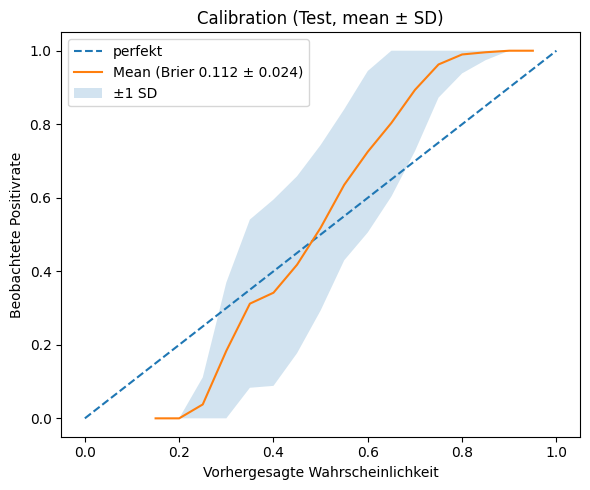

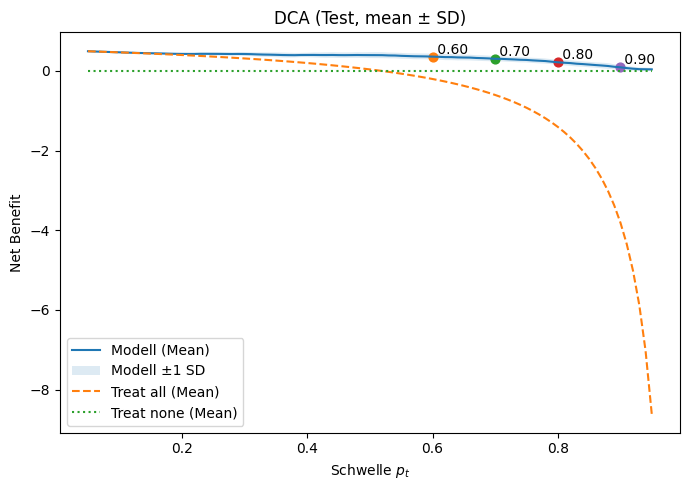


Internal OOF 95% CIs (Bootstrap)
AUROC: 0.949 (0.910–0.979)
AUPRC: 0.958 (0.924–0.984)
Brier: 0.111 (0.090–0.133)

Fixed threshold (Youden on OOF): 0.513

Internal thresholded metrics at t=0.51 (Bootstrap 95% CIs)
Accuracy: 0.889 (0.824–0.944)
F1: 0.887 (0.818–0.942)
Precision: 0.940 (0.865–1.000)
Recall: 0.839 (0.741–0.925)

External performance 95% CIs (Bootstrap)
AUROC: 0.770 (0.646–0.876)
AUPRC: 0.744 (0.628–0.877)
Brier: 0.449 (0.409–0.475)
Accuracy: 0.537 (0.522–0.567)
F1: 0.061 (0.000–0.171)
Precision: 1.000 (0.000–1.000)
Recall: 0.031 (0.000–0.094)

Calibration (point estimates):
  Intercept (CITL): 2.797
  Slope:            0.294
  Brier:            0.449

External calibration 95% CIs (Bootstrap)
Intercept: 2.797 (1.383–5.611)
Slope: 0.294 (0.155–0.572)
Brier: 0.449 (0.409–0.475)
ECE: 0.463 (0.413–0.497)


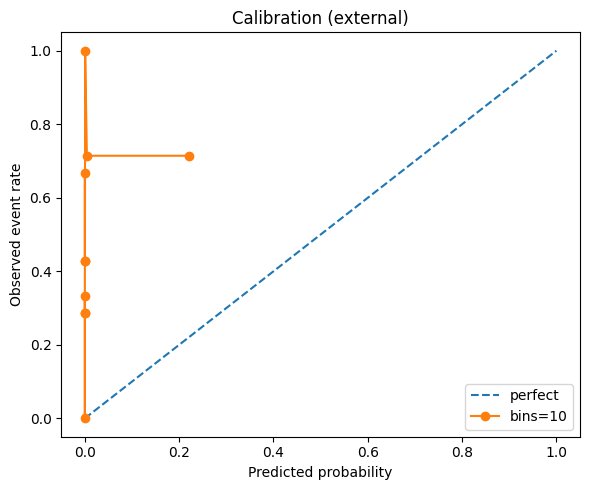

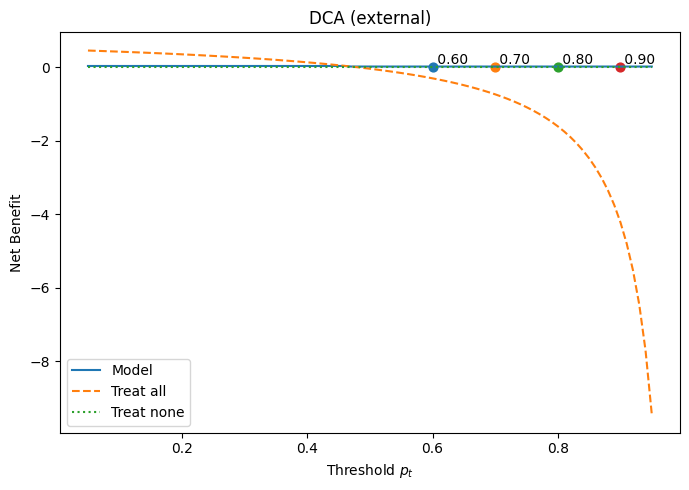

In [5]:

import os
import json
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from joblib import dump, load

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, brier_score_loss, roc_curve, average_precision_score)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

# =======================
# KONFIGURATION
# =======================
CONFIG = {
    "target_col": "Verletzungsstatus",
    "normalize_headers": False,    # auf True setzen, wenn du Header robust normalisieren willst
    "ignore_cols": [],             # optional: z.B. IDs, die nicht in die Features dürfen
    "model_name": "logreg",        # "logreg" oder "svc"
    "logreg": {
        "solver": "liblinear",
        "penalty": "l2",
        "C": 1.0,
        "class_weight": None,      # oder "balanced"
        "max_iter": 200
    },
    "svc": {
        "kernel": "rbf",
        "C": 1.0,
        "gamma": "scale",
        "class_weight": None,      # oder "balanced"
        "calibrate": True,         # True: CalibratedClassifierCV, False: SVC(probability=True)
        "calibration_method": "sigmoid",
        "calibration_cv": 5
    },
    "cv": {
        "splits": 5,
        "repeats": 10,
        "random_state": 42
    },
    "artifacts_prefix": "locked_slim"
}

# =======================
# Utility (optional Header-Normalizer)
# =======================
import re
def _norm_header(s: str) -> str:
    if s is None: return ""
    s = str(s)
    s = s.replace("\u00A0"," ").replace("\u2009"," ").replace("\u202F"," ").replace("\u2007"," ")
    s = re.sub(r"[_\-\–\—/\\\|\;]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"\.\s*$", "", s)
    return s.lower()

def maybe_normalize_headers(df: pd.DataFrame) -> pd.DataFrame:
    if not CONFIG["normalize_headers"]:
        return df
    cols = [_norm_header(c) for c in df.columns]
    # duplikate handhaben:
    seen = {}
    out_cols = []
    for c in cols:
        if c not in seen:
            seen[c] = 1
            out_cols.append(c)
        else:
            seen[c] += 1
            out_cols.append(f"{c}_dup{seen[c]}")
    df2 = df.copy()
    df2.columns = out_cols
    return df2

# =======================
# Calibration & DCA
# =======================
def compute_calibration(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    bs = brier_score_loss(y_true, y_prob)
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy="quantile")
    return {"brier": bs, "mean_pred": mean_pred, "frac_pos": frac_pos}

def decision_curve(y_true, y_prob, thresholds=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    N = len(y_true)
    prevalence = y_true.mean()
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)

    nb_model, nb_all = [], []
    nb_none = np.zeros_like(thresholds)
    for pt in thresholds:
        pred = (y_prob >= pt).astype(int)
        TP = np.sum((pred == 1) & (y_true == 1))
        FP = np.sum((pred == 1) & (y_true == 0))
        weight = pt / (1 - pt)
        nb_model.append((TP / N) - (FP / N) * weight)
        nb_all.append(prevalence - (1 - prevalence) * weight)
    return {
        "thresholds": np.array(thresholds),
        "nb_model": np.array(nb_model),
        "nb_all": np.array(nb_all),
        "nb_none": nb_none,
        "prevalence": prevalence
    }

def aggregate_calibration(cal_list, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)
    mats = []
    for c in cal_list:
        mp = np.asarray(c["mean_pred"]); fp = np.asarray(c["frac_pos"])
        valid = (~np.isnan(mp)) & (~np.isnan(fp))
        if valid.sum() >= 2:
            interp = np.interp(grid, mp[valid], fp[valid], left=np.nan, right=np.nan)
        else:
            interp = np.full_like(grid, np.nan, dtype=float)
        mats.append(interp)
    M = np.vstack(mats)
    briers = np.array([c["brier"] for c in cal_list if "brier" in c])
    return {
        "grid": grid,
        "mean_frac_pos": np.nanmean(M, axis=0),
        "std_frac_pos":  np.nanstd(M, axis=0),
        "brier_mean": float(np.mean(briers)) if len(briers) else np.nan,
        "brier_std":  float(np.std(briers))  if len(briers) else np.nan
    }

def aggregate_dca(dca_list, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 91)
    nb_m, nb_a, nb_n = [], [], []
    for d in dca_list:
        th = np.asarray(d["thresholds"])
        nb_m.append(np.interp(grid, th, np.asarray(d["nb_model"])))
        nb_a.append(np.interp(grid, th, np.asarray(d["nb_all"])))
        nb_n.append(np.interp(grid, th, np.asarray(d["nb_none"])))
    nb_m = np.vstack(nb_m); nb_a = np.vstack(nb_a); nb_n = np.vstack(nb_n)
    return {
        "thresholds": grid,
        "nb_model_mean": np.mean(nb_m, axis=0), "nb_model_std": np.std(nb_m, axis=0),
        "nb_all_mean":   np.mean(nb_a, axis=0), "nb_all_std":   np.std(nb_a, axis=0),
        "nb_none_mean":  np.mean(nb_n, axis=0), "nb_none_std":  np.std(nb_n, axis=0),
    }

def plot_calibration_mean(cal_agg, title="Calibration (mean ± SD)"):
    g   = cal_agg["grid"]
    mu  = cal_agg["mean_frac_pos"]
    sd  = cal_agg["std_frac_pos"]
    bsM = cal_agg["brier_mean"]
    bsS = cal_agg["brier_std"]
    plt.figure(figsize=(6,5))
    plt.plot([0,1],[0,1],'--',label="perfekt")
    plt.plot(g, mu, label=f"Mean (Brier {bsM:.3f} ± {bsS:.3f})")
    plt.fill_between(g, np.maximum(mu - sd, 0), np.minimum(mu + sd, 1), alpha=0.2, label="±1 SD")
    plt.xlabel("Vorhergesagte Wahrscheinlichkeit"); plt.ylabel("Beobachtete Positivrate")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def plot_dca_mean(dca_agg, mark_pts=None, title="DCA (mean ± SD)"):
    th = dca_agg["thresholds"]
    plt.figure(figsize=(7,5))
    plt.plot(th, dca_agg["nb_model_mean"], label="Modell (Mean)")
    plt.fill_between(th,
                     dca_agg["nb_model_mean"]-dca_agg["nb_model_std"],
                     dca_agg["nb_model_mean"]+dca_agg["nb_model_std"],
                     alpha=0.15, label="Modell ±1 SD")
    plt.plot(th, dca_agg["nb_all_mean"], '--', label="Treat all (Mean)")
    plt.plot(th, dca_agg["nb_none_mean"], ':',  label="Treat none (Mean)")
    if mark_pts is not None:
        for pt in mark_pts:
            if th.min() <= pt <= th.max():
                idx = np.argmin(np.abs(th - pt))
                y = dca_agg["nb_model_mean"][idx]
                plt.scatter([th[idx]],[y], s=40)
                plt.text(th[idx], y, f" {pt:.2f}", va='bottom')
    plt.xlabel("Schwelle $p_t$"); plt.ylabel("Net Benefit")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

# =======================
# Bootstrap-Intervalle & Kalibration
# =======================
def print_ci_block(title, stats_dict):
    print(f"\n{title}")
    for k, (pt, (lo, hi)) in stats_dict.items():
        print(f"{k}: {pt:.3f} ({lo:.3f}–{hi:.3f})")

def bootstrap_ci_internal_oof(y, p, B=2000, seed=42):
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    idx = np.arange(len(y))
    pt_auroc = roc_auc_score(y, p)
    pt_auprc = average_precision_score(y, p)
    pt_brier = brier_score_loss(y, p)
    A,U,Bs = [],[],[]
    for _ in range(B):
        s = rng.choice(idx, size=len(idx), replace=True)
        A.append(roc_auc_score(y[s], p[s]))
        U.append(average_precision_score(y[s], p[s]))
        Bs.append(brier_score_loss(y[s], p[s]))
    pct = lambda v: (float(np.percentile(v,2.5)), float(np.percentile(v,97.5)))
    return {"AUROC": (pt_auroc, pct(A)),
            "AUPRC": (pt_auprc, pct(U)),
            "Brier": (pt_brier, pct(Bs))}

def bootstrap_ci_thresholded(y, p, thr, B=2000, seed=42):
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    idx = np.arange(len(y))
    def safe(f, yt, yp):
        try: return f(yt, yp)
        except Exception: return float("nan")
    def metrics(y_, p_):
        yhat = (p_ >= thr).astype(int)
        return (accuracy_score(y_, yhat),
                safe(f1_score, y_, yhat),
                safe(precision_score, y_, yhat),
                safe(recall_score, y_, yhat))
    pt = metrics(y, p)
    ACC,F1,PR,RE = [],[],[],[]
    for _ in range(B):
        s = rng.choice(idx, size=len(idx), replace=True)
        a,f,pr,re = metrics(y[s], p[s])
        ACC.append(a); F1.append(f); PR.append(pr); RE.append(re)
    pct = lambda v: (float(np.nanpercentile(v,2.5)), float(np.nanpercentile(v,97.5)))
    return {"Accuracy": (pt[0], pct(ACC)),
            "F1":       (pt[1], pct(F1)),
            "Precision":(pt[2], pct(PR)),
            "Recall":   (pt[3], pct(RE))}

from sklearn.linear_model import LogisticRegression as _LR  # reuse import above
def _logit(p, eps=1e-8):
    p = np.clip(p, eps, 1-eps)
    return np.log(p/(1-p))

def calibration_intercept_slope(y, p):
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    X = _logit(p).reshape(-1,1)
    lr = _LR(max_iter=1000).fit(X, y)
    slope = float(lr.coef_[0,0]); intercept = float(lr.intercept_[0])
    brier = brier_score_loss(y, p)
    return intercept, slope, brier

def expected_calibration_error(y, p, n_bins=10):
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
    w = np.full_like(mean_pred, 1.0/len(mean_pred))
    return float(np.sum(w * np.abs(mean_pred - frac_pos)))

def bootstrap_ci_external(y, p, thr, B=2000, seed=42):
    import numpy as np
    from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                                 accuracy_score, f1_score, precision_score, recall_score)

    # Robust gegen np.float*
    B = int(B)

    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    def safe(f, yt, yp):
        try:
            return f(yt, yp)
        except Exception:
            return float("nan")

    def metrics(y_, p_):
        yhat = (p_ >= thr).astype(int)
        auroc = roc_auc_score(y_, p_)
        auprc = safe(average_precision_score, y_, p_)
        brier = brier_score_loss(y_, p_)
        acc   = accuracy_score(y_, yhat)
        f1    = safe(f1_score, y_, yhat)
        prec  = safe(precision_score, y_, yhat)
        rec   = safe(recall_score, y_, yhat)
        return auroc, auprc, brier, acc, f1, prec, rec

    # Punktwerte
    pt = metrics(y, p)

    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    n_pos, n_neg = int(idx_pos.size), int(idx_neg.size)

    A, U, Bs, Ac, F1, Pr, Re = [], [], [], [], [], [], []
    for _ in range(B):
        if n_pos > 0 and n_neg > 0:
            pos = rng.choice(idx_pos, size=n_pos, replace=True)
            neg = rng.choice(idx_neg, size=n_neg, replace=True)
            s = np.concatenate([pos, neg])
        else:
            s = rng.choice(np.arange(len(y)), size=len(y), replace=True)

        a, u, b, ac, f, pr, re = metrics(y[s], p[s])
        A.append(a); U.append(u); Bs.append(b); Ac.append(ac); F1.append(f); Pr.append(pr); Re.append(re)

    pct = lambda v: (float(np.nanpercentile(v, 2.5)), float(np.nanpercentile(v, 97.5)))
    return {
        "AUROC":    (pt[0], pct(A)),
        "AUPRC":    (pt[1], pct(U)),
        "Brier":    (pt[2], pct(Bs)),
        "Accuracy": (pt[3], pct(Ac)),
        "F1":       (pt[4], pct(F1)),
        "Precision":(pt[5], pct(Pr)),
        "Recall":   (pt[6], pct(Re)),
    }

def bootstrap_ci_calibration(y, p, B=2000, seed=42, n_bins=10):
    import numpy as np
    # Robust gegen np.float* / Floats
    B = int(B)
    n_bins = int(n_bins)

    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    def calib(y_, p_):
        I, S, Brier = calibration_intercept_slope(y_, p_)
        E = expected_calibration_error(y_, p_, n_bins=n_bins)
        return I, S, Brier, E

    I, S, Brier, E = calib(y, p)

    I_, S_, B_, E_ = [], [], [], []
    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    n_pos, n_neg = int(idx_pos.size), int(idx_neg.size)

    for _ in range(B):
        if n_pos > 0 and n_neg > 0:
            pos = rng.choice(idx_pos, size=n_pos, replace=True)
            neg = rng.choice(idx_neg, size=n_neg, replace=True)
            s = np.concatenate([pos, neg])
        else:
            # Fallback falls eine Klasse leer ist
            s = rng.choice(np.arange(len(y)), size=len(y), replace=True)

        i, s_, b, e = calib(y[s], p[s])
        I_.append(i); S_.append(s_); B_.append(b); E_.append(e)

    pct = lambda v: (float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5)))
    return {
        "Intercept": (I, pct(I_)),
        "Slope":     (S, pct(S_)),
        "Brier":     (Brier, pct(B_)),
        "ECE":       (E, pct(E_)),
    }


# =======================
# Model builder (Umschalter)
# =======================
def build_estimator(name: str):
    if name.lower() == "logreg":
        p = CONFIG["logreg"]
        return LogisticRegression(
            solver=p["solver"],
            penalty=p["penalty"],
            C=p["C"],
            class_weight=p["class_weight"],
            max_iter=p["max_iter"]
        )
    elif name.lower() == "svc":
        p = CONFIG["svc"]
        if p["calibrate"]:
            base = SVC(kernel=p["kernel"], C=p["C"], gamma=p["gamma"],
                       class_weight=p["class_weight"], probability=False)
            return CalibratedClassifierCV(base_estimator=base,
                                          method=p["calibration_method"],
                                          cv=p["calibration_cv"])
        else:
            return SVC(kernel=p["kernel"], C=p["C"], gamma=p["gamma"],
                       class_weight=p["class_weight"], probability=True)
    else:
        raise ValueError("model_name must be 'logreg' or 'svc'.")

# =======================
# CV-Pipeline (ohne Augmentation)
# =======================
def run_cv_pipeline(data_path, target_column="Verletzungsstatus",
                    cv_splits=5, cv_repeats=10, verbose=True):
    try:
        df = pd.read_excel(data_path, sheet_name=0)
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

    df = maybe_normalize_headers(df)
    if target_column not in df.columns:
        print(f"Target column '{target_column}' not in data.")
        return None

    y = df[target_column].astype(int)
    X = df.drop(columns=[target_column] + CONFIG["ignore_cols"], errors="ignore").copy()

    if verbose:
        print(f"Data loaded: {len(df)} samples, {X.shape[1]} features")
        try:
            print(f"Class distribution: {y.value_counts().to_dict()}")
        except Exception:
            pass

    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats,
                                 random_state=CONFIG["cv"]["random_state"])

    metrics_results, cal_list, dca_list = [], [], []

    oof_true  = y.to_numpy().astype(int)
    oof_pred  = np.zeros(len(X), dtype=float)
    oof_sum   = np.zeros(len(X), dtype=float)
    oof_count = np.zeros(len(X), dtype=int)

    model_name = CONFIG["model_name"]
    for fold, (tr, te) in enumerate(cv.split(X, y), start=1):
        if verbose:
            print(f"\n--- Fold {fold} ---")
        X_train, y_train = X.iloc[tr].copy(), y.iloc[tr].copy()
        X_test,  y_test  = X.iloc[te].copy(), y.iloc[te].copy()

        scaler = MinMaxScaler()
        X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
        X_test_sc  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index)

        est = build_estimator(model_name)
        est.fit(X_train_sc, y_train)

        # Vorhersagen (Probas)
        if hasattr(est, "predict_proba"):
            y_pred_prob = est.predict_proba(X_test_sc)[:,1]
            y_train_prob = est.predict_proba(X_train_sc)[:,1]
        else:
            # Fallback: decision_function → via sigmoid auf (0,1) bringen
            from scipy.special import expit
            y_pred_prob = expit(est.decision_function(X_test_sc))
            y_train_prob = expit(est.decision_function(X_train_sc))

        oof_sum[te]   += y_pred_prob
        oof_count[te] += 1

        # temporäre binäre 0.5-Schwelle (nur für Fold-Reporting)
        y_pred = (y_pred_prob >= 0.5).astype(int)
        train_pred = (y_train_prob >= 0.5).astype(int)

        fold_metrics = {
            'train_accuracy': accuracy_score(y_train, train_pred),
            'test_accuracy':  accuracy_score(y_test, y_pred),
            'f1_score':       f1_score(y_test, y_pred, zero_division=0),
            'precision':      precision_score(y_test, y_pred, zero_division=0),
            'recall':         recall_score(y_test, y_pred, zero_division=0),
            'roc_auc':        roc_auc_score(y_test, y_pred_prob),
        }
        cal = compute_calibration(y_test.values, y_pred_prob, n_bins=10)
        fold_metrics['brier_score'] = cal["brier"]
        cal_list.append(cal)

        dca = decision_curve(y_test.values, y_pred_prob, thresholds=np.linspace(0.05,0.95,91))
        dca_list.append(dca)

        metrics_results.append(fold_metrics)

    # OOF mitteln
    mask = oof_count > 0
    oof_pred[mask] = oof_sum[mask] / oof_count[mask]

    # Aggregierte Tables
    results_df = pd.DataFrame(metrics_results)
    mean_metrics = results_df.mean(numeric_only=True)
    std_metrics  = results_df.std(numeric_only=True)
    aggregated_scalar_metrics = {"mean": mean_metrics.to_dict(), "std": std_metrics.to_dict()}

    cal_agg = aggregate_calibration(cal_list, grid=np.linspace(0.05, 0.95, 19))
    dca_agg = aggregate_dca(dca_list, grid=np.linspace(0.05, 0.95, 91))

    return aggregated_scalar_metrics, cal_agg, dca_agg, (oof_true, oof_pred, df, X.columns.tolist())

# =======================
# Youden & Freezing
# =======================
def determine_fixed_threshold_youden(oof_true, oof_pred):
    fpr, tpr, thr = roc_curve(oof_true, oof_pred)
    j = tpr - fpr
    return float(thr[np.argmax(j)])

def freeze_pipeline_for_external(df, feature_order, fixed_threshold, save_prefix="locked_slim"):
    y_all = df[CONFIG["target_col"]].astype(int).to_numpy()
    X_all = df.drop(columns=[CONFIG["target_col"]] + CONFIG["ignore_cols"], errors="ignore").copy()
    # exakt gleiche Spaltenreihenfolge
    X_all = X_all[feature_order].copy()

    scaler = MinMaxScaler()
    X_all_sc = pd.DataFrame(scaler.fit_transform(X_all), columns=feature_order)

    est = build_estimator(CONFIG["model_name"])
    est.fit(X_all_sc, y_all)

    dump(est, f"{save_prefix}_model.joblib")
    dump(scaler, f"{save_prefix}_scaler.joblib")
    dump(feature_order, f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json", "w") as f:
        json.dump({"fixed_threshold": float(fixed_threshold),
                   "target_col": CONFIG["target_col"],
                   "model_name": CONFIG["model_name"]}, f)

# =======================
# Externe Validierung
# =======================
def plot_calibration_single(y, p, n_bins=10, title="Calibration (external)"):
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
    plt.figure(figsize=(6,5))
    plt.plot([0,1], [0,1], '--', label="perfect")
    plt.plot(mean_pred, frac_pos, marker='o', label=f"bins={n_bins}")
    plt.xlabel("Predicted probability"); plt.ylabel("Observed event rate")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def plot_dca_single(dca, mark_pts=None, title="DCA (external)"):
    th = dca["thresholds"]
    plt.figure(figsize=(7,5))
    plt.plot(th, dca["nb_model"], label="Model")
    plt.plot(th, dca["nb_all"], '--', label="Treat all")
    plt.plot(th, dca["nb_none"], ':', label="Treat none")
    if mark_pts is not None:
        for pt in mark_pts:
            if th.min() <= pt <= th.max():
                idx = np.argmin(np.abs(th - pt))
                y = dca["nb_model"][idx]
                plt.scatter([th[idx]],[y], s=40)
                plt.text(th[idx], y, f" {pt:.2f}", va='bottom')
    plt.xlabel("Threshold $p_t$"); plt.ylabel("Net Benefit")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def external_validate_locked(external_path, save_prefix="locked_slim",
                             n_bins=10, dca_marks=[0.60,0.70,0.80,0.90]):
    est   = load(f"{save_prefix}_model.joblib")
    scaler = load(f"{save_prefix}_scaler.joblib")
    feature_order = load(f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json","r") as f:
        meta = json.load(f)
    thr = float(meta["fixed_threshold"]); target_col = meta["target_col"]

    df_ext = pd.read_excel(external_path, sheet_name=0)
    df_ext = maybe_normalize_headers(df_ext)

    X_ext = df_ext[feature_order].copy()   # identische Spaltenreihenfolge
    y_ext = df_ext[target_col].astype(int).to_numpy()

    X_ext_sc = pd.DataFrame(scaler.transform(X_ext), columns=feature_order)
    if hasattr(est, "predict_proba"):
        p_ext = est.predict_proba(X_ext_sc)[:,1]
    else:
        from scipy.special import expit
        p_ext = expit(est.decision_function(X_ext_sc))

    stats = bootstrap_ci_external(y_ext, p_ext, thr, B=2000)
    print_ci_block("External performance 95% CIs (Bootstrap)", stats)

    I,S,B = calibration_intercept_slope(y_ext, p_ext)
    print(f"\nCalibration (point estimates):")
    print(f"  Intercept (CITL): {I:.3f}")
    print(f"  Slope:            {S:.3f}")
    print(f"  Brier:            {B:.3f}")

    cal_ci = bootstrap_ci_calibration(y_ext, p_ext, B=2000, n_bins=n_bins)
    print_ci_block("External calibration 95% CIs (Bootstrap)", cal_ci)
    plot_calibration_single(y_ext, p_ext, n_bins=n_bins, title="Calibration (external)")

    dca = decision_curve(y_ext, p_ext, thresholds=np.linspace(0.05,0.95,91))
    plot_dca_single(dca, mark_pts=dca_marks, title="DCA (external)")

# =======================
# MAIN
# =======================
def main():
    # ==== PFADE ANPASSEN ====
    INTERNAL_PATH = r"K:\Team\Böhmer_Michael\PAPER\Finale_Versionen_ML_Vergleich\Basistabelle_ML_reduziert.xlsx"
    EXTERNAL_PATH = r"K:\Team\Böhmer_Michael\PAPER\Finale_Versionen_ML_Vergleich\Basistabelle_Maestroni_ML.xlsx"
    # ========================

    res = run_cv_pipeline(
        INTERNAL_PATH,
        target_column=CONFIG["target_col"],
        cv_splits=CONFIG["cv"]["splits"],
        cv_repeats=CONFIG["cv"]["repeats"],
        verbose=True
    )
    if res is None:
        print("Pipeline failed."); return
    aggregated_results, cal_agg, dca_agg, (oof_true, oof_pred, df_all, feature_order) = res

    print("\n=== Model Performance Summary (CV folds) ===")
    print("{:<15} {:<20} {:<20}".format("Metric", "Mean", "Std"))
    for metric, mean_val in aggregated_results["mean"].items():
        std_val = aggregated_results["std"].get(metric, np.nan)
        print("{:<15} {:<20.4f} {:<20.4f}".format(metric, mean_val, std_val))

    plot_calibration_mean(cal_agg, title="Calibration (Test, mean ± SD)")
    plot_dca_mean(dca_agg, mark_pts=[0.60,0.70,0.80,0.90], title="DCA (Test, mean ± SD)")

    oof_ci = bootstrap_ci_internal_oof(oof_true, oof_pred, B=2000)
    print_ci_block("Internal OOF 95% CIs (Bootstrap)", oof_ci)

    fixed_threshold = determine_fixed_threshold_youden(oof_true, oof_pred)
    print(f"\nFixed threshold (Youden on OOF): {fixed_threshold:.3f}")

    th_ci = bootstrap_ci_thresholded(oof_true, oof_pred, thr=fixed_threshold, B=2000)
    print_ci_block(f"Internal thresholded metrics at t={fixed_threshold:.2f} (Bootstrap 95% CIs)", th_ci)

    # Freeze Artefakte
    freeze_pipeline_for_external(df_all, feature_order, fixed_threshold, save_prefix=CONFIG["artifacts_prefix"])

    # Externe Validierung
    if os.path.exists(EXTERNAL_PATH):
        external_validate_locked(EXTERNAL_PATH, save_prefix=CONFIG["artifacts_prefix"],
                                 n_bins=10, dca_marks=[0.60,0.70,0.80,0.90])
    else:
        print(f"\n[Hint] External validation file not found:\n{EXTERNAL_PATH}\n"
              f"→ Set EXTERNAL_PATH to your file and re-run.")

if __name__ == "__main__":
    main()
